In [9]:
import boto3, random, base64, json, io
from PIL import Image, ImageDraw, ImageFont
ENDPOINT_NAME = 'YOLOv8-CFU-SageMaker-endpoint' 

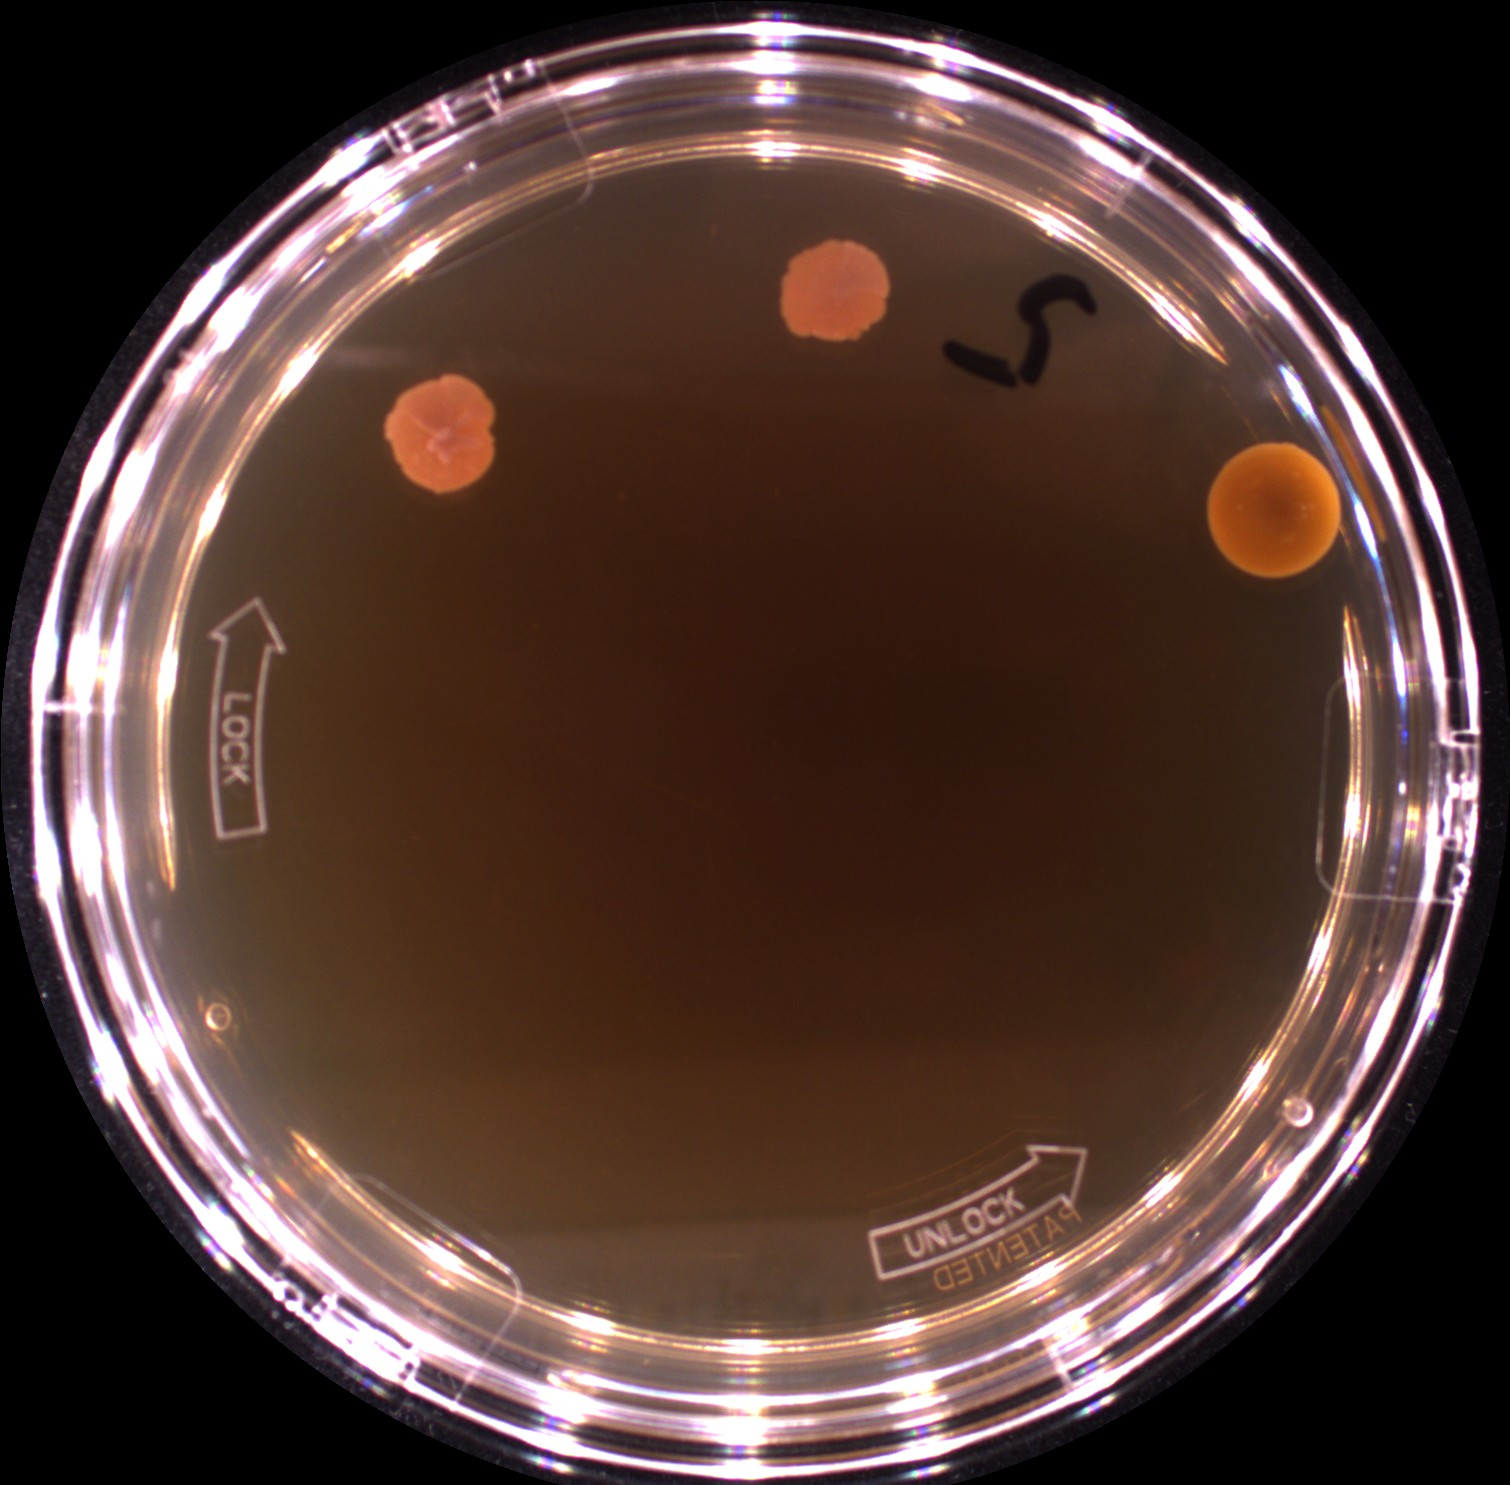

In [14]:
# Read the image from file
orig_image = Image.open('cfu_positive.jpg')
# Show the original image
orig_image

In [15]:
# Calculate the parameters for image resizing
image_height, image_width = orig_image.size
model_height, model_width = 640, 640
x_ratio = image_width/model_width
y_ratio = image_height/model_height

# Resize the image recieved to the size the model accepts
resizedImage = orig_image.resize((model_height, model_width), Image.Resampling.LANCZOS)

In [16]:
# Convert the resized image to the jpeg and save the jpeg as a byte stream 
img_byte_arr = io.BytesIO()
resizedImage.save(img_byte_arr, format='jpeg')

# Convert tyhe bytes into base64
payload = base64.b64encode(img_byte_arr.getvalue())

In [13]:
# Call the endpoint, supplying the base64 string
runtime= boto3.client('runtime.sagemaker')
response = runtime.invoke_endpoint(EndpointName=ENDPOINT_NAME,
                                        ContentType='text/csv',
                                        Body=payload)
response_body = response['Body'].read()
result = json.loads(response_body.decode('ascii'))
# Print out the result
result

{'boxes': [[506.23095703125,
   184.70162963867188,
   571.8258056640625,
   254.6337890625,
   0.9250338077545166,
   2.0],
  [157.13467407226562,
   155.04345703125,
   217.92916870117188,
   220.50234985351562,
   0.9133425951004028,
   2.0],
  [323.40545654296875,
   95.53266906738281,
   382.56121826171875,
   154.10154724121094,
   0.8978055119514465,
   2.0],
  [358.99053955078125,
   481.6905517578125,
   467.85992431640625,
   561.256103515625,
   0.8867478370666504,
   8.0],
  [74.20674133300781,
   250.18934631347656,
   131.54600524902344,
   372.0732421875,
   0.8392903208732605,
   4.0],
  [393.03759765625,
   110.6873550415039,
   472.19140625,
   174.74099731445312,
   0.7842460870742798,
   5.0],
  [81.64431762695312,
   425.52703857421875,
   103.282470703125,
   447.88470458984375,
   0.3213026821613312,
   1.0]]}

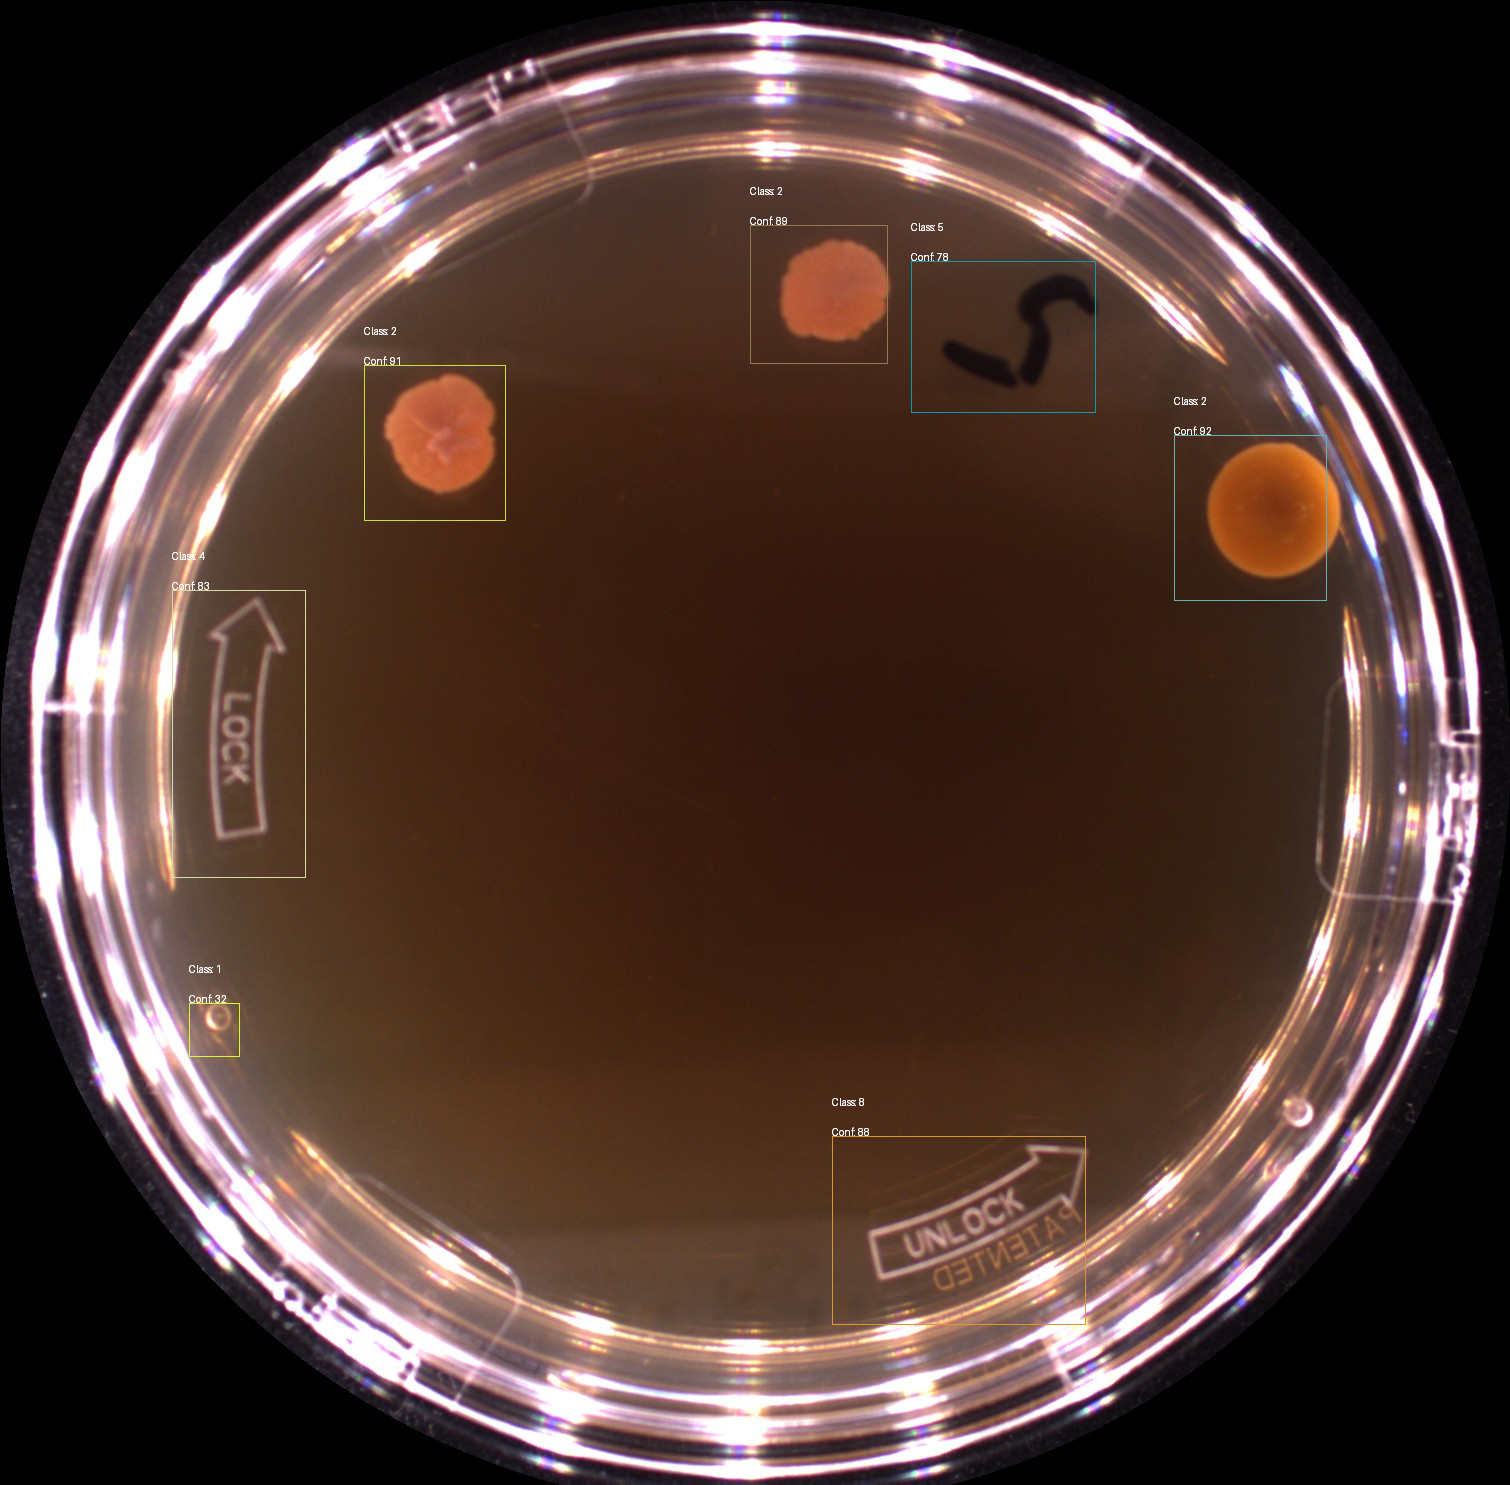

In [18]:
# Draw the boxes on the original image
if 'boxes' in result:
    draw = ImageDraw.Draw(orig_image)
    for idx,(x1,y1,x2,y2,conf,lbl) in enumerate(result['boxes']):
        # Draw Bounding Boxes
        # Calculate the boxes coordinates scaled to the size of the original image
        x1, x2 = int(x_ratio*x1), int(x_ratio*x2)
        y1, y2 = int(y_ratio*y1), int(y_ratio*y2)
        color = (random.randint(10,255), random.randint(10,255), random.randint(10,255))
        draw.rectangle(((x1,y1), (x2,y2)), outline = color)
        draw.text((x1,y1-40), f"Class: {int(lbl)}")
        draw.text((x1,y1-10), f"Conf: {int(conf*100)}")
# Show the original image with the boxes drawn
orig_image